In [2]:
'''
get_zdFF.py calculates standardized dF/F signal based on calcium-idependent 
and calcium-dependent signals commonly recorded using fiber photometry calcium imaging

Ocober 2019 Ekaterina Martianova ekaterina.martianova.1@ulaval.ca 

Reference:
  (1) Martianova, E., Aronson, S., Proulx, C.D. Multi-Fiber Photometry 
      to Record Neural Activity in Freely Moving Animal. J. Vis. Exp. 
      (152), e60278, doi:10.3791/60278 (2019)
      https://www.jove.com/video/60278/multi-fiber-photometry-to-record-neural-activity-freely-moving

'''

def get_zdFF(reference,signal,smooth_win=10,remove=200,lambd=5e4,porder=1,itermax=50): 
  '''
  Calculates z-score dF/F signal based on fiber photometry calcium-idependent 
  and calcium-dependent signals
  
  Input
      reference: calcium-independent signal (usually 405-420 nm excitation), 1D array
      signal: calcium-dependent signal (usually 465-490 nm excitation for 
                   green fluorescent proteins, or ~560 nm for red), 1D array
      smooth_win: window for moving average smooth, integer
      remove: the beginning of the traces with a big slope one would like to remove, integer
      Inputs for airPLS:
      lambd: parameter that can be adjusted by user. The larger lambda is,  
              the smoother the resulting background, z
      porder: adaptive iteratively reweighted penalized least squares for baseline fitting
      itermax: maximum iteration times
  Output
      zdFF - z-score dF/F, 1D numpy array
  '''
  
  import numpy as np
  from sklearn.linear_model import Lasso

 # Smooth signal
  reference = smooth_signal(reference, smooth_win)
  signal = smooth_signal(signal, smooth_win)
  
 # Remove slope using airPLS algorithm
  r_base=airPLS(reference,lambda_=lambd,porder=porder,itermax=itermax)
  s_base=airPLS(signal,lambda_=lambd,porder=porder,itermax=itermax) 

 # Remove baseline and the begining of recording
  reference = (reference[remove:] - r_base[remove:])
  signal = (signal[remove:] - s_base[remove:])   

 # Standardize signals    
  reference = (reference - np.median(reference)) / np.std(reference)
  signal = (signal - np.median(signal)) / np.std(signal)
  
 # Align reference signal to calcium signal using non-negative robust linear regression
  lin = Lasso(alpha=0.0001,precompute=True,max_iter=1000,
              positive=True, random_state=9999, selection='random')
  n = len(reference)
  lin.fit(reference.reshape(n,1), signal.reshape(n,1))
  reference = lin.predict(reference.reshape(n,1)).reshape(n,)

 # z dFF    
  zdFF = (signal - reference)
 
  return zdFF

In [3]:
def smooth_signal(x,window_len=10,window='flat'):

    """smooth the data using a window with requested size.
    
    This method is based on the convolution of a scaled window with the signal.
    The signal is prepared by introducing reflected copies of the signal 
    (with the window size) in both ends so that transient parts are minimized
    in the begining and end part of the output signal.
    The code taken from: https://scipy-cookbook.readthedocs.io/items/SignalSmooth.html
    
    input:
        x: the input signal 
        window_len: the dimension of the smoothing window; should be an odd integer
        window: the type of window from 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'
                'flat' window will produce a moving average smoothing.

    output:
        the smoothed signal        
    """

    import numpy as np

    if x.ndim != 1:
        raise(ValueError, "smooth only accepts 1 dimension arrays.")

    if x.size < window_len:
        raise(ValueError, "Input vector needs to be bigger than window size.")

    if window_len<3:
        return x

    if not window in ['flat', 'hanning', 'hamming', 'bartlett', 'blackman']:
        raise(ValueError, "Window is one of 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'")

    s=np.r_[x[window_len-1:0:-1],x,x[-2:-window_len-1:-1]]

    if window == 'flat': # Moving average
        w=np.ones(window_len,'d')
    else:
        w=eval('np.'+window+'(window_len)')

    y=np.convolve(w/w.sum(),s,mode='valid')

    return y[(int(window_len/2)-1):-int(window_len/2)]

In [4]:
'''
airPLS.py Copyright 2014 Renato Lombardo - renato.lombardo@unipa.it
Baseline correction using adaptive iteratively reweighted penalized least squares

This program is a translation in python of the R source code of airPLS version 2.0
by Yizeng Liang and Zhang Zhimin - https://code.google.com/p/airpls

Reference:
Z.-M. Zhang, S. Chen, and Y.-Z. Liang, Baseline correction using adaptive iteratively 
reweighted penalized least squares. Analyst 135 (5), 1138-1146 (2010).

Description from the original documentation:
Baseline drift always blurs or even swamps signals and deteriorates analytical 
results, particularly in multivariate analysis.  It is necessary to correct baseline 
drift to perform further data analysis. Simple or modified polynomial fitting has 
been found to be effective in some extent. However, this method requires user 
intervention and prone to variability especially in low signal-to-noise ratio 
environments. The proposed adaptive iteratively reweighted Penalized Least Squares
(airPLS) algorithm doesn't require any user intervention and prior information, 
such as detected peaks. It iteratively changes weights of sum squares errors (SSE) 
between the fitted baseline and original signals, and the weights of SSE are obtained 
adaptively using between previously fitted baseline and original signals. This 
baseline estimator is general, fast and flexible in fitting baseline.


LICENCE
This program is free software: you can redistribute it and/or modify
it under the terms of the GNU Lesser General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU Lesser General Public License for more details.

You should have received a copy of the GNU Lesser General Public License
along with this program.  If not, see <http://www.gnu.org/licenses/>
'''

import numpy as np
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve

def WhittakerSmooth(x,w,lambda_,differences=1):
    '''
    Penalized least squares algorithm for background fitting
    
    input
        x: input data (i.e. chromatogram of spectrum)
        w: binary masks (value of the mask is zero if a point belongs to peaks and one otherwise)
        lambda_: parameter that can be adjusted by user. The larger lambda is,  the smoother the resulting background
        differences: integer indicating the order of the difference of penalties
    
    output
        the fitted background vector
    '''
    X=np.matrix(x)
    m=X.size
    i=np.arange(0,m)
    E=eye(m,format='csc')
    D=E[1:]-E[:-1] # numpy.diff() does not work with sparse matrix. This is a workaround.
    W=diags(w,0,shape=(m,m))
    A=csc_matrix(W+(lambda_*D.T*D))
    B=csc_matrix(W*X.T)
    background=spsolve(A,B)
    return np.array(background)

def airPLS(x, lambda_=100, porder=1, itermax=15):
    '''
    Adaptive iteratively reweighted penalized least squares for baseline fitting
    
    input
        x: input data (i.e. chromatogram of spectrum)
        lambda_: parameter that can be adjusted by user. The larger lambda is,
                 the smoother the resulting background, z
        porder: adaptive iteratively reweighted penalized least squares for baseline fitting
    
    output
        the fitted background vector
    '''
    m=x.shape[0]
    w=np.ones(m)
    for i in range(1,itermax+1):
        z=WhittakerSmooth(x,w,lambda_, porder)
        d=x-z
        dssn=np.abs(d[d<0].sum())
        if(dssn<0.001*(abs(x)).sum() or i==itermax):
            if(i==itermax): print('WARING max iteration reached!')
            break
        w[d>=0]=0 # d>0 means that this point is part of a peak, so its weight is set to 0 in order to ignore it
        w[d<0]=np.exp(i*np.abs(d[d<0])/dssn)
        w[0]=np.exp(i*(d[d<0]).max()/dssn) 
        w[-1]=w[0]
    return z


/home/kceniabougrova/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Option 1: same length :)
470 =  124347  415 =  124347


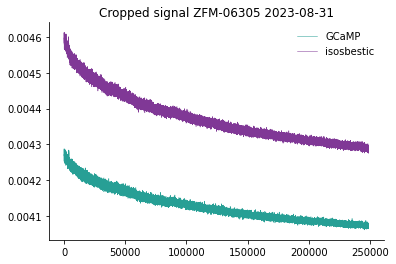

470 = 124347  415 = 124347


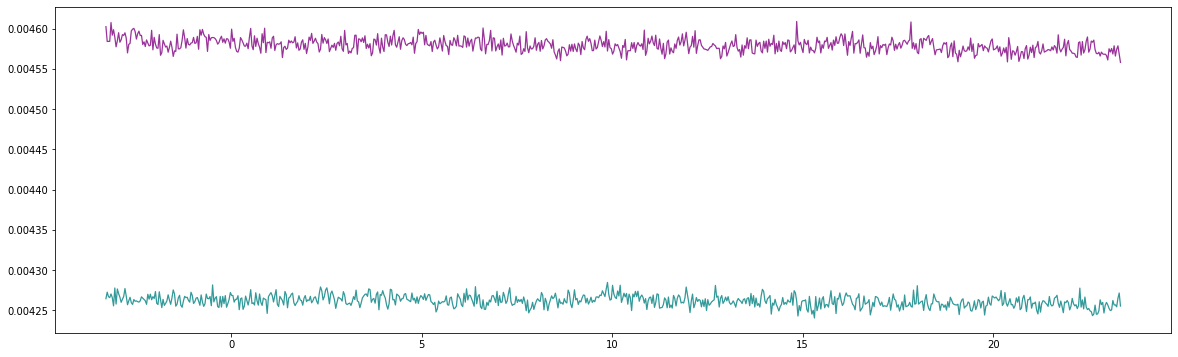

In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from brainbox.behavior.training import compute_performance 
from brainbox.io.one import SessionLoader 
# import iblphotometry.kcenia as kcenia
import ibldsp.utils
import scipy.signal
from iblutil.numerical import rcoeff
from functions import *
import sys
sys.path.insert(0, "/home/kceniabougrova/Documents/GitHub/ibl-photometry/src")

from one.api import ONE #always after the imports 
# one = ONE(cache_dir="/mnt/h0/kb/data/one") 
one = ONE() 

""" useful""" 
# eids = one.search(project='ibl_fibrephotometry') 

#%%
#===========================================================================
#                            Pick data from table 
#===========================================================================

table_path = '/home/kceniabougrova/Documents/NM_project_fromIBLserver/NM_project2/KB_sessions_insertions_map - upload.csv'
sessions_list = pd.read_csv(table_path)

def select_one_session(sessions_list=sessions_list, row=150): 
    eid = sessions_list.loc[row, "eid"]
    subject = sessions_list.loc[row, "subject"]
    date = sessions_list.loc[row, "date"]
    region = sessions_list.loc[row, "region"]
    nph_file_path = sessions_list.loc[row, "photometry_path_a"]
    nph_bnc_path = sessions_list.loc[row, "digital_inputs_path"]
    return eid, subject, date, region, nph_file_path, nph_bnc_path


eid, subject, date, region, nph_file_path, nph_bnc_path = select_one_session(row=450)
# Replace the prefix in the paths if needed
old_prefix = '/mnt/h0/kb/'
new_prefix = '/media/kceniabougrova/Seagate Basic/IBL_server_PC_20250529/kb/'

nph_file_path = nph_file_path.replace(old_prefix, new_prefix)
nph_bnc_path = nph_bnc_path.replace(old_prefix, new_prefix)

# Load the CSVs
df_nph = pd.read_csv(nph_file_path)
df_bnc = pd.read_csv(nph_bnc_path)



#%%
""" EDIT THE VARS - eid, ROI, photometry file path (.csv or .pqt) """
eid = '56ed83ac-c196-4817-bc37-62c02ba89d47' #example eid 

#choose one: .csv or .pqt
nph_file_path = '/media/kceniabougrova/Seagate Basic/IBL_server_PC_20250529/kb/data/one/mainenlab/Subjects/ZFM-06305/2023-08-31/001/raw_photometry_data/raw_photometry.csv' 
nph_bnc_path = '/media/kceniabougrova/Seagate Basic/IBL_server_PC_20250529/kb/data/external_drive/2023-08-31/bonsai_DI10.csv'
df_nph = pd.read_csv(nph_file_path) 
df_bnc = pd.read_csv(nph_bnc_path) 
# df_nph = pd.read_parquet(nph_file_path) 

region_number = 3
region_number = 4




alldata = pd.read_csv('/home/kceniabougrova/Downloads/KB_sessions_insertions_map - sessions_table(1).csv')

#%%


df_trials, subject, session_date = load_trials_updated(eid) 

#%% #########################################################################################################
""" GET PHOTOMETRY DATA """ 

region = f"Region{region_number}G"

df_nph["mouse"] = subject
df_nph["date"] = session_date
df_nph["region"] = region
df_nph["eid"] = eid 
nph_bnc = df_bnc

# Remove 'Value.' prefix from columns
nph_bnc.columns = [col.replace("Value.", "") for col in nph_bnc.columns]
nph_bnc = nph_bnc[nph_bnc["Value"] == True].reset_index(drop=True)

tph = df_bnc["Timestamp"].values


"""
CHANGE INPUT AUTOMATICALLY 
""" 
# tph = (df_nph['Timestamp'].values[iup] + df_nph['Timestamp'].values[iup - 1]) / 2 #nph TTL times computed for the midvalue 
tbpod = np.sort(np.r_[
    df_trials['intervals_0'].values,
    df_trials['intervals_1'].values - 1,  # here is the trick
    df_trials.loc[df_trials['feedbackType'] == 1, 'feedback_times'].values]
)

fcn_nph_to_bpod_times, drift_ppm = ibldsp.utils.sync_timestamps(tph, tbpod, linear=True)

df_nph["bpod_frame_times"] = fcn_nph_to_bpod_times(df_nph["Timestamp"]) 

fcn_nph_to_bpod_times(df_nph["Timestamp"])


# df_trials = df_trials[0:len(df_trials)-1] #to avoid the last trial not having photometry data 
session_start = df_trials.intervals_0.values[0] - 10  # Start time, 100 seconds before the first tph value
session_end = df_trials.intervals_1.values[-1] + 10   # End time, 100 seconds after the last tph value

# Select data within the specified time range
selected_data = df_nph[
    (df_nph['bpod_frame_times'] >= session_start) &
    (df_nph['bpod_frame_times'] <= session_end)
] 
df_nph = selected_data.reset_index(drop=True) 


#%%
#===========================================================================
#      4. FUNCTIONS TO LOAD DATA AND ADD SOME VARIABLES (BEHAVIOR)
#===========================================================================
df_nph = LedState_or_Flags(df_nph)

""" 4.1.2 Check for LedState/previous Flags bugs """ 
""" 4.1.2.1 Length """
# Verify the length of the data of the 2 different LEDs
df_470, df_415 = verify_length(df_nph)
""" 4.1.2.2 Verify if there are repeated flags """ 
verify_repetitions(df_nph["LedState"])
""" 4.1.3 Remove "weird" data (flag swap, huge signal) """ 
# session_day=rec.date
# plot_outliers(df_470,df_415,region,mouse,session_day) 

df_ph_1 = df_nph

# Remove rows with LedState 1 at both ends if present
if df_ph_1['LedState'].iloc[0] == 1 and df_ph_1['LedState'].iloc[-1] == 1:
    df_ph_1 = df_ph_1.iloc[1:]

# Remove rows with LedState 2 at both ends if present
if df_ph_1['LedState'].iloc[0] == 2 and df_ph_1['LedState'].iloc[-1] == 2:
    df_ph_1 = df_ph_1.iloc[:-2]

# Filter data for LedState 2 (470nm)
df_470 = df_ph_1[df_ph_1['LedState'] == 2]

# Filter data for LedState 1 (415nm)
df_415 = df_ph_1[df_ph_1['LedState'] == 1]

# Check if the lengths of df_470 and df_415 are equal
assert len(df_470) == len(df_415), "Sync arrays are of different lengths"

# Plot the data
plt.rcParams["figure.figsize"] = (8, 5)
plt.plot(df_470[region], c='#279F95', linewidth=0.5)
plt.plot(df_415[region], c='#803896', linewidth=0.5)
plt.title("Cropped signal "+subject+' '+str(session_date))
plt.legend(["GCaMP", "isosbestic"], frameon=False)
sns.despine(left=False, bottom=False)
plt.show(block=False)
plt.close() 
# Print counts
print("470 =", df_470['LedState'].count(), " 415 =", df_415['LedState'].count())

df_nph = df_ph_1.reset_index(drop=True)  
df_470 = df_nph[df_nph.LedState==2] 
df_470 = df_470.reset_index(drop=True)
df_415 = df_nph[df_nph.LedState==1] 
df_415 = df_415.reset_index(drop=True) 
#================================================
""" 4.1.4 FRAME RATE """ 
time_diffs = (df_470["Timestamp"]).diff().dropna() 
fs = 1 / time_diffs.median() 

raw_reference = df_415[region] #isosbestic 
raw_signal = df_470[region] #GCaMP signal 
raw_timestamps_bpod = df_470["bpod_frame_times"]
raw_timestamps_nph_470 = df_470["Timestamp"]
raw_timestamps_nph_415 = df_415["Timestamp"]
raw_TTL_bpod = tbpod
raw_TTL_nph = tph

# my_array = np.c_[raw_timestamps_bpod, raw_reference, raw_signal]
my_array = np.column_stack((raw_timestamps_bpod, raw_reference, raw_signal))

df_nph = pd.DataFrame(my_array, columns=['times', 'raw_isosbestic', 'raw_calcium']) #IMPORTANT DF

plt.figure(figsize=(20, 6))
plt.plot(df_nph['times'][200:1000], df_nph['raw_calcium'][200:1000], linewidth=1.25, alpha=0.8, color='teal') 
plt.plot(df_nph['times'][200:1000], df_nph['raw_isosbestic'][200:1000], linewidth=1.25, alpha=0.8, color='purple') 
plt.show() 

import pandas as pd
import matplotlib.pyplot as plt



In [6]:
df_nph

,times,raw_isosbestic,raw_calcium
0,-9.954491,0.004597,0.004268
1,-9.921180,0.004597,0.004274
2,-9.887836,0.004595,0.004278
3,-9.854492,0.004598,0.004268
4,-9.821180,0.004594,0.004263
...,...,...,...
124342,4134.626279,0.004293,0.004079
124343,4134.659622,0.004281,0.004069
124344,4134.692966,0.004291,0.004076
124345,4134.726278,0.004290,0.004078


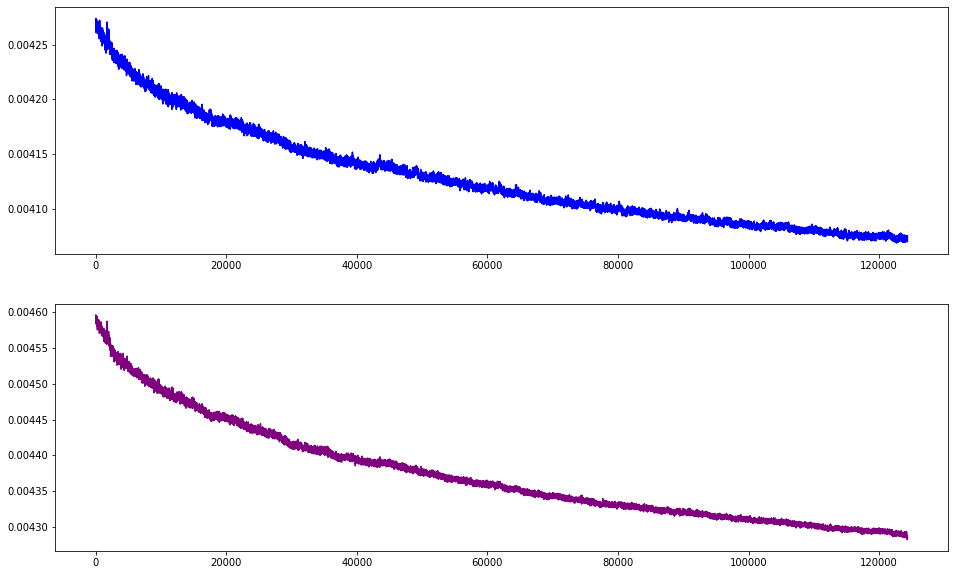

In [7]:


raw_reference = df_nph['raw_isosbestic'][1:]
raw_signal = df_nph['raw_calcium'][1:]

smooth_win = 10
smooth_reference = smooth_signal(raw_reference, smooth_win)
smooth_signal = smooth_signal(raw_signal, smooth_win) 

fig = plt.figure(figsize=(16, 10))
ax1 = fig.add_subplot(211)
ax1.plot(smooth_signal,'blue',linewidth=1.5)
ax2 = fig.add_subplot(212)
ax2.plot(smooth_reference,'purple',linewidth=1.5)


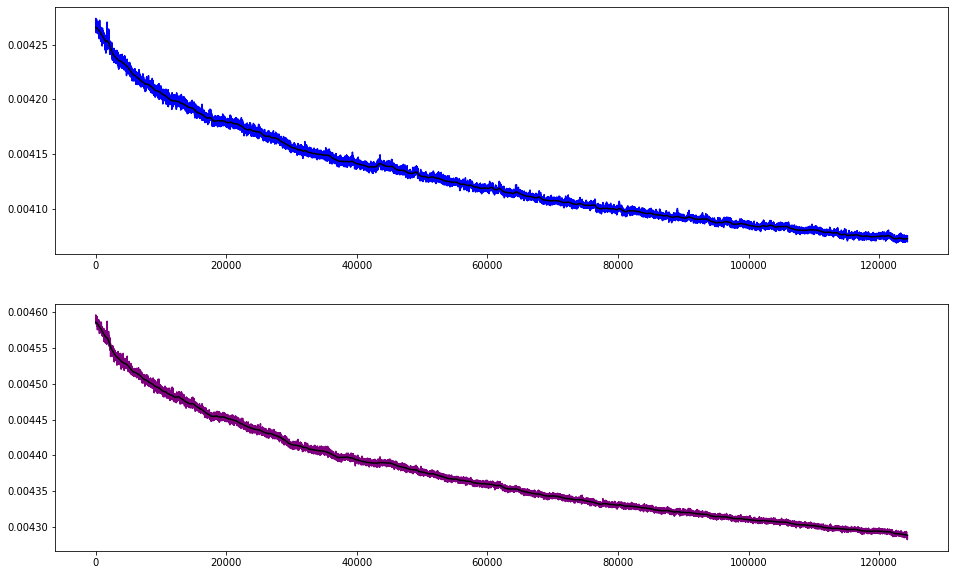

In [8]:

lambd = 5e4 # Adjust lambda to get the best fit
porder = 1
itermax = 50
r_base=airPLS(smooth_reference.T,lambda_=lambd,porder=porder,itermax=itermax)
s_base=airPLS(smooth_signal,lambda_=lambd,porder=porder,itermax=itermax)

fig = plt.figure(figsize=(16, 10))
ax1 = fig.add_subplot(211)
ax1.plot(smooth_signal,'blue',linewidth=1.5)
ax1.plot(s_base,'black',linewidth=1.5)
ax2 = fig.add_subplot(212)
ax2.plot(smooth_reference,'purple',linewidth=1.5)
ax2.plot(r_base,'black',linewidth=1.5)


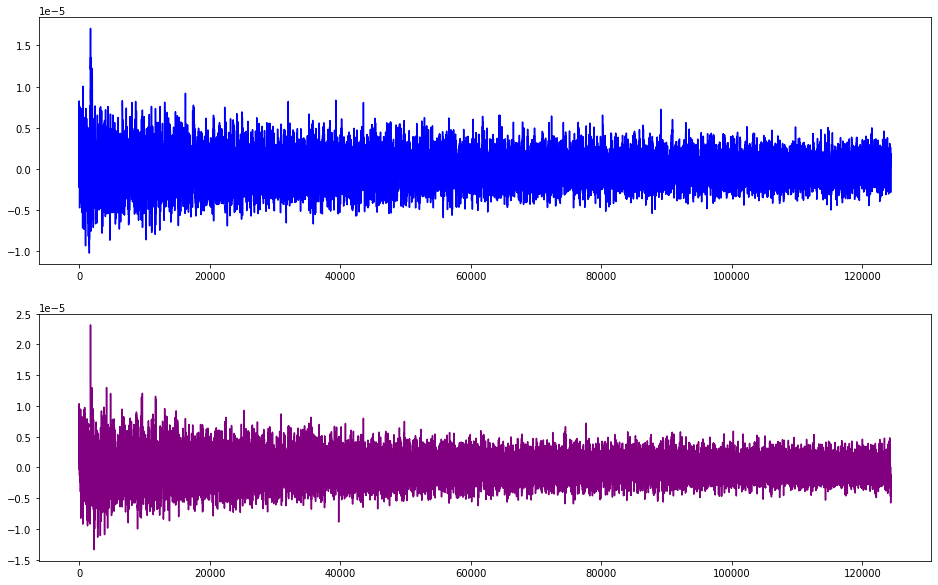

In [13]:

remove=0
reference = (smooth_reference[remove:] - r_base[remove:])
signal = (smooth_signal[remove:] - s_base[remove:])  

fig = plt.figure(figsize=(16, 10))
ax1 = fig.add_subplot(211)
ax1.plot(signal,'blue',linewidth=1.5)
ax2 = fig.add_subplot(212)
ax2.plot(reference,'purple',linewidth=1.5)


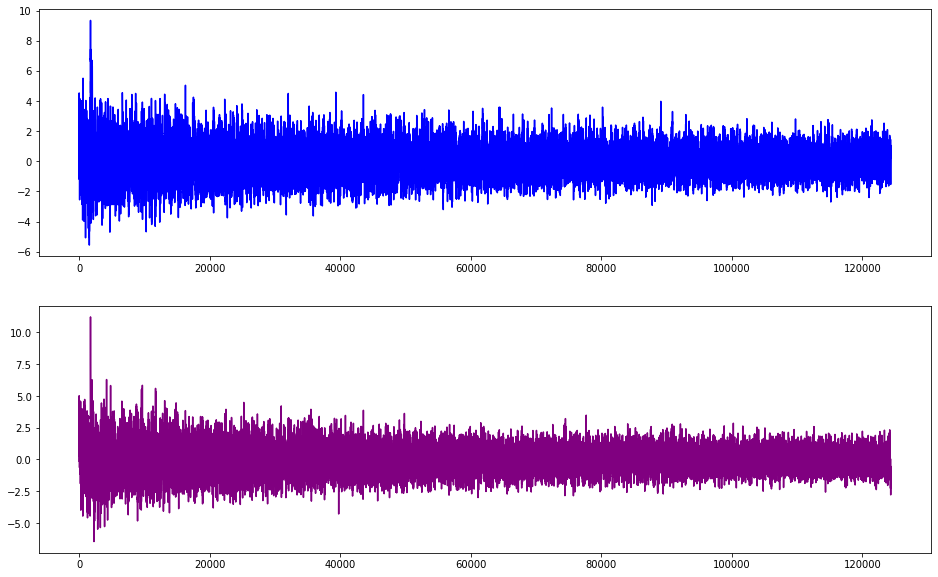

In [14]:

z_reference = (reference - np.median(reference)) / np.std(reference)
z_signal = (signal - np.median(signal)) / np.std(signal)

fig = plt.figure(figsize=(16, 10))
ax1 = fig.add_subplot(211)
ax1.plot(z_signal,'blue',linewidth=1.5)
ax2 = fig.add_subplot(212)
ax2.plot(z_reference,'purple',linewidth=1.5)



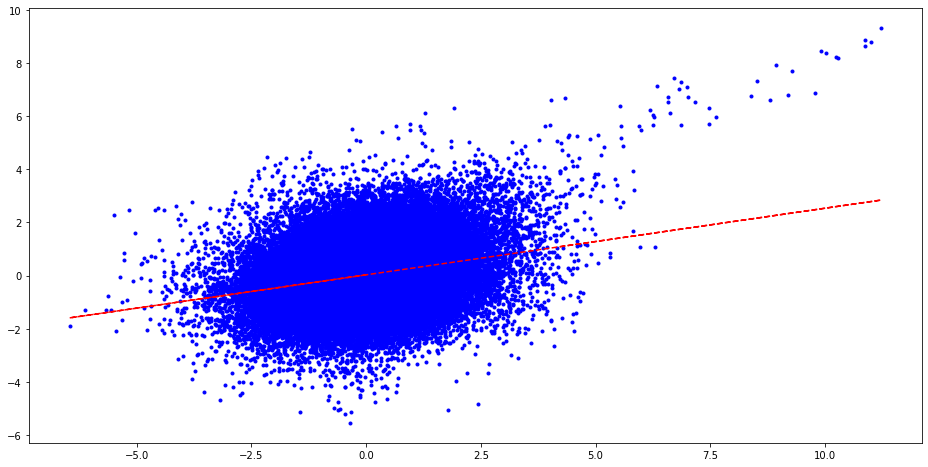

In [16]:
from sklearn.linear_model import Lasso
lin = Lasso(alpha=0.0001,precompute=True,max_iter=1000,
            positive=True, random_state=9999, selection='random')
n = len(z_reference)
lin.fit(z_reference.reshape(n,1), z_signal.reshape(n,1))

z_reference_fitted = lin.predict(z_reference.reshape(n,1)).reshape(n,)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(111)
ax1.plot(z_reference,z_signal,'b.')
ax1.plot(z_reference,z_reference_fitted, 'r--',linewidth=1.5)


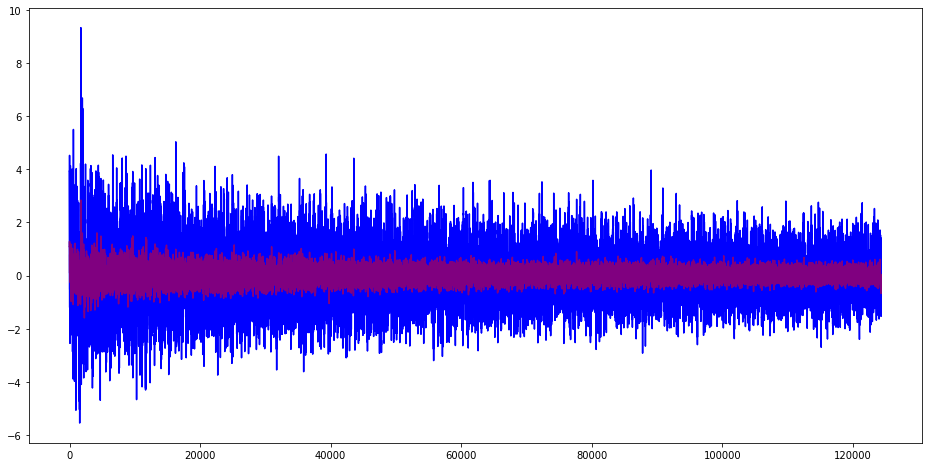

In [17]:
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(111)
ax1.plot(z_signal,'blue')
ax1.plot(z_reference_fitted,'purple')


In [18]:
zdFF = (z_signal - z_reference_fitted)

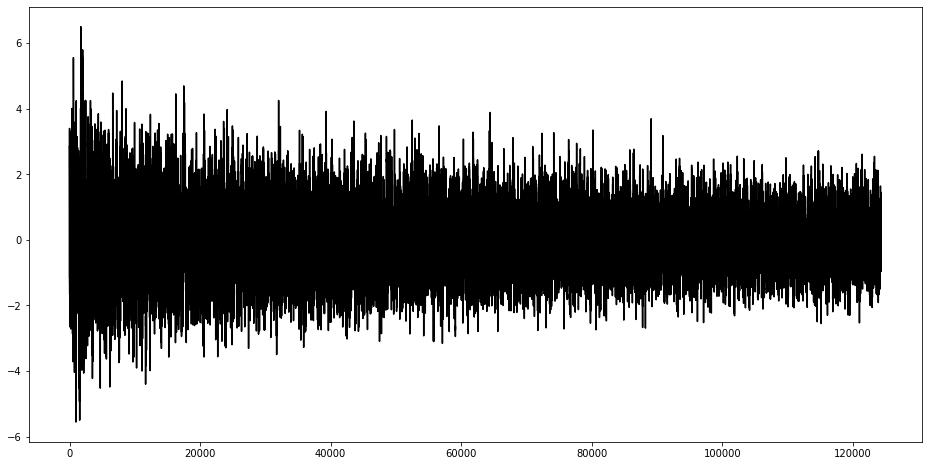

In [19]:
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(111)
ax1.plot(zdFF,'black')

In [21]:
len(zdFF)

124346

In [22]:
df_nph

,times,raw_isosbestic,raw_calcium
0,-9.954491,0.004597,0.004268
1,-9.921180,0.004597,0.004274
2,-9.887836,0.004595,0.004278
3,-9.854492,0.004598,0.004268
4,-9.821180,0.004594,0.004263
...,...,...,...
124342,4134.626279,0.004293,0.004079
124343,4134.659622,0.004281,0.004069
124344,4134.692966,0.004291,0.004076
124345,4134.726278,0.004290,0.004078
